# Variant zoom-in finder (representative run)

For the representative run (`nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75` run 14),
this ranks the **GARW** model's per-variant growth-rate MAE, takes the top ~5%,
de-duplicates windows that share the same `(pivot_date, deme)` (so each window is plotted
once), and renders the fig-4-style zoom-in for each so high-error windows can be screened
for failure-mode examples that mimic the main-text figure. The chosen window list at the
end is what the main-text fig-4 (GARW) and the FGA supplement (S6) should reuse.

**Prerequisite (run on HPC where the model posteriors live, then scp down):** the model
growth-rate median+HPD comes from the per-run `estimates/` dir, which is git-ignored and
absent locally. Pull it to the batch-root results dir so the helpers resolve it:

```
scp -r rhino.fhcrc.org:'/fh/fast/matsen_e/zthornto/antigen-forecasting/results/2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_14/estimates' \
  /Users/zo/projects/research/antigen-forecasting/results/2026-07-04-reviewer-runs/
```

Run with the repo root on `PYTHONPATH` (so `antigentools` imports) from `notebooks/`.


In [1]:
# import sys
# # antigentools lives at the repo root and is not pip-installed in the env; add the repo
# # root (the parent of notebooks/) to the path so it imports under any kernel, including
# # VSCode's, which does not set PYTHONPATH. Matches manuscript-figure-5 / figS5.
# sys.path.append("..")

import glob
from typing import Optional, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import evofr as ef

from IPython.display import display, Markdown

from antigentools.analysis import get_filtered_growth_rates_df
from antigentools.plot import get_analysis_window, print_window_stats


/Users/zo/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Configuration -----------------------------------------------------------
# BUILD resolves BOTH ../data/<BUILD>/ (run-14 data staged at the batch root) and
# ../results/<BUILD>/estimates/ (scp the run-14 estimates there; see the title cell).
BUILD = "2026-07-04-reviewer-runs"
MODEL = "GARW"  # focus: the FGA supplement reuses the same windows chosen here.

# The per-run scores live nested (results were not flattened like the data), so the
# ranking file is read by its explicit path.
RUN_RESULTS = "../results/2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_14"

TOP_FRAC = 0.05       # take the top 5% of variant-windows by MAE.
MAX_WINDOWS = None    # optional cap on how many unique windows to plot (None = all).

# Growth-rate filtering / spline params, matching fig-4.
MIN_SEQUENCE_COUNT = 10
MIN_VARIANT_FREQUENCY = 0.01
MIN_VARIANT_INCIDENCE = 50.0
SPLINE_SMOOTHING_FACTOR = 1.0
SPLINE_ORDER = 3


In [3]:
def create_variant_color_map(tips_df, variant_col="variant_ag", time_col="year"):
    """Golden-ratio color map keyed by variant id (lifted from figure-2)."""
    order = tips_df.groupby(variant_col)[time_col].min().sort_values().index.tolist()
    golden = 0.618033988749895
    colors = []
    for i in range(len(order)):
        hue = (i * golden) % 1.0
        sat, val = [(0.9, 0.95), (0.7, 0.85), (0.85, 0.75)][i % 3]
        colors.append(mcolors.rgb2hex(mcolors.hsv_to_rgb([hue, sat, val])))
    return {v: colors[i] for i, v in enumerate(order)}


# Build the variant color map from the run's tips (no saved auspice map for run 14).
# The fig-4 panels index color_map[v_name] directly, and v_name can be int or str
# depending on the source, so key the map on both forms.
_tips = pd.read_csv(f"../data/{BUILD}/tips_with_variants.tsv", sep="\t")
_base = create_variant_color_map(_tips, "variant_ag", "year")
color_map = {}
for k, v in _base.items():
    color_map[int(k)] = v
    color_map[str(k)] = v
print(f"color map: {len(_base)} variants")


color map: 30 variants


In [ ]:
# Third copy of these panels, now imported from antigentools rather than redefined.
# This notebook draws on an 11-inch canvas, and scale_for_canvas(11.0) gives
# label_fontsize=14 -- exactly the value that was hardcoded here -- so nothing
# about how it renders changes.
from antigentools.growth_rate_panels import (
    plot_frequencies_nowcast_only,
    plot_observed_cases_clean,
    plot_r_data_vs_r_model_clean,
    plot_variant_incidence_panel,
)
from antigentools.supplement_style import scale_for_canvas

FINDER_CANVAS_WIDTH_IN = 11.0
FINDER_SIZES = scale_for_canvas(FINDER_CANVAS_WIDTH_IN)


In [5]:
def plot_window_zoomin(pivot_date, location, model, build, color_map,
                       label_fontsize=FINDER_SIZES["label"], p_freq=50, p_r=95):
    """Render the 4-panel fig-4-style zoom-in for a single analysis window."""
    growth_rates_df = get_filtered_growth_rates_df(
        build, model, location, pivot_date,
        spline_smoothing_factor=SPLINE_SMOOTHING_FACTOR, spline_order=SPLINE_ORDER,
        min_sequence_count=MIN_SEQUENCE_COUNT,
        min_variant_frequency=MIN_VARIANT_FREQUENCY,
        min_variant_incidence=MIN_VARIANT_INCIDENCE,
    )
    dummy_fitness_df = pd.DataFrame(
        columns=["date", "location", "variant", "fitness", "seasonal_fitness", "t"]
    )
    evo_dict, small_freqs_df, small_rt_df, small_fitness_df = get_analysis_window(
        pivot_date, build, dummy_fitness_df
    )
    print_window_stats(evo_dict, location)
    pivot_idx = small_freqs_df.query(f"date == '{pivot_date}'")["t"].values[0]

    current_variants = set(evo_dict[location].var_names)
    filtered_color_map = {k: v for k, v in color_map.items() if k in current_variants}

    fig, axes = plt.subplots(4, 1, figsize=(11, 13), sharex=True)
    fig.suptitle(f"{model} inference — {location} deme, pivot {pivot_date}", fontsize=16)
    plot_observed_cases_clean(axes[0], evo_dict, location, pivot_idx=[pivot_idx],
                              label_fontsize=label_fontsize)
    plot_frequencies_nowcast_only(axes[1], evo_dict, small_freqs_df, location, model,
                                  filtered_color_map, p=p_freq, pivot_idx=[pivot_idx],
                                  label_fontsize=label_fontsize)
    plot_variant_incidence_panel(axes[2], growth_rates_df, location, filtered_color_map, evo_dict,
                           pivot_idx=[pivot_idx], label_fontsize=label_fontsize)
    plot_r_data_vs_r_model_clean(axes[3], growth_rates_df, location, filtered_color_map,
                                 evo_dict, pivot_idx=[pivot_idx],
                                 label_fontsize=label_fontsize, p=p_r)
    axes[3].set_xlabel("Time (t, days within window)", fontsize=label_fontsize)
    plt.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()
    plt.close(fig)


In [6]:
# Rank GARW converged variant-windows by MAE; take the top fraction.
gr = pd.read_csv(f"{RUN_RESULTS}/variant_growth_rates.tsv", sep="\t")
g = gr[(gr["model"] == MODEL) & (gr["converged"] == True)].copy()
g["log_mae"] = np.log(g["mae"] + 1e-6)
thr = g["mae"].quantile(1 - TOP_FRAC)
top = g[g["mae"] >= thr].sort_values("mae", ascending=False)
print(f"{MODEL}: {len(top)} variant-windows in the top {TOP_FRAC:.0%} (mae >= {thr:.4f})")
display(top[["variant", "pivot_date", "location", "mae", "r2", "n_points"]])

# De-duplicate to unique (pivot_date, location) windows so each is plotted once.
windows = (
    top.groupby(["pivot_date", "location"])
    .agg(variants=("variant", lambda s: sorted(s.unique())), max_mae=("mae", "max"))
    .reset_index()
    .sort_values("max_mae", ascending=False)
)
if MAX_WINDOWS is not None:
    windows = windows.head(MAX_WINDOWS)
print(f"{len(windows)} unique (pivot_date, location) windows to plot")
display(windows)


GARW: 9 variant-windows in the top 5% (mae >= 0.0371)


,variant,pivot_date,location,mae,r2,n_points
232,0,2025-04-01,north,0.076404,-12.546393,8
234,2,2025-04-01,north,0.067625,-7.874718,11
233,1,2025-04-01,north,0.065877,-11.657443,11
396,10,2032-10-01,tropics,0.046981,-6.238068,33
383,5,2030-04-01,tropics,0.044849,-37.453302,17
351,22,2045-04-01,south,0.043525,-2.041884,24
350,21,2045-04-01,south,0.040634,-5.448884,16
308,4,2029-10-01,south,0.040084,0.403487,5
286,22,2044-10-01,north,0.037930,-0.650377,15


6 unique (pivot_date, location) windows to plot


,pivot_date,location,variants,max_mae
0,2025-04-01,north,"[0, 1, 2]",0.076404
3,2032-10-01,tropics,[10],0.046981
2,2030-04-01,tropics,[5],0.044849
5,2045-04-01,south,"[21, 22]",0.043525
1,2029-10-01,south,[4],0.040084
4,2044-10-01,north,[22],0.037930


### north — pivot 2025-04-01  (variants [0, 1, 2], max MAE 0.0764)

Total cases: 8822831.0
Total sequences: 4188.0
Variant counts: [ 747. 2879.  562.]


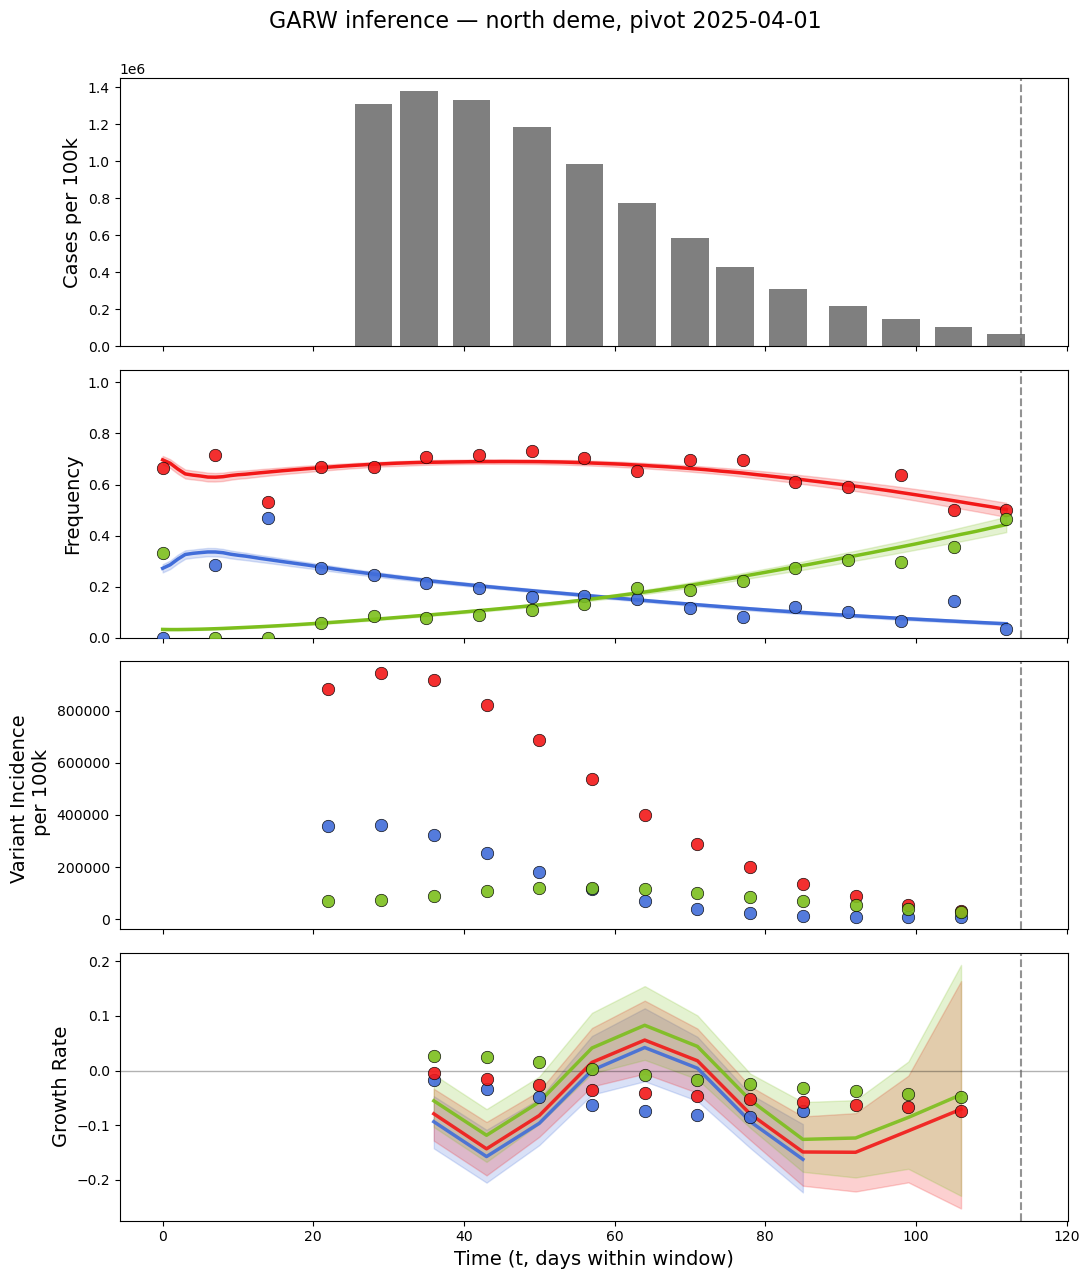

### tropics — pivot 2032-10-01  (variants [10], max MAE 0.0470)

Total cases: 9229512.0
Total sequences: 4633.0
Variant counts: [  15. 2153. 2423.   42.]


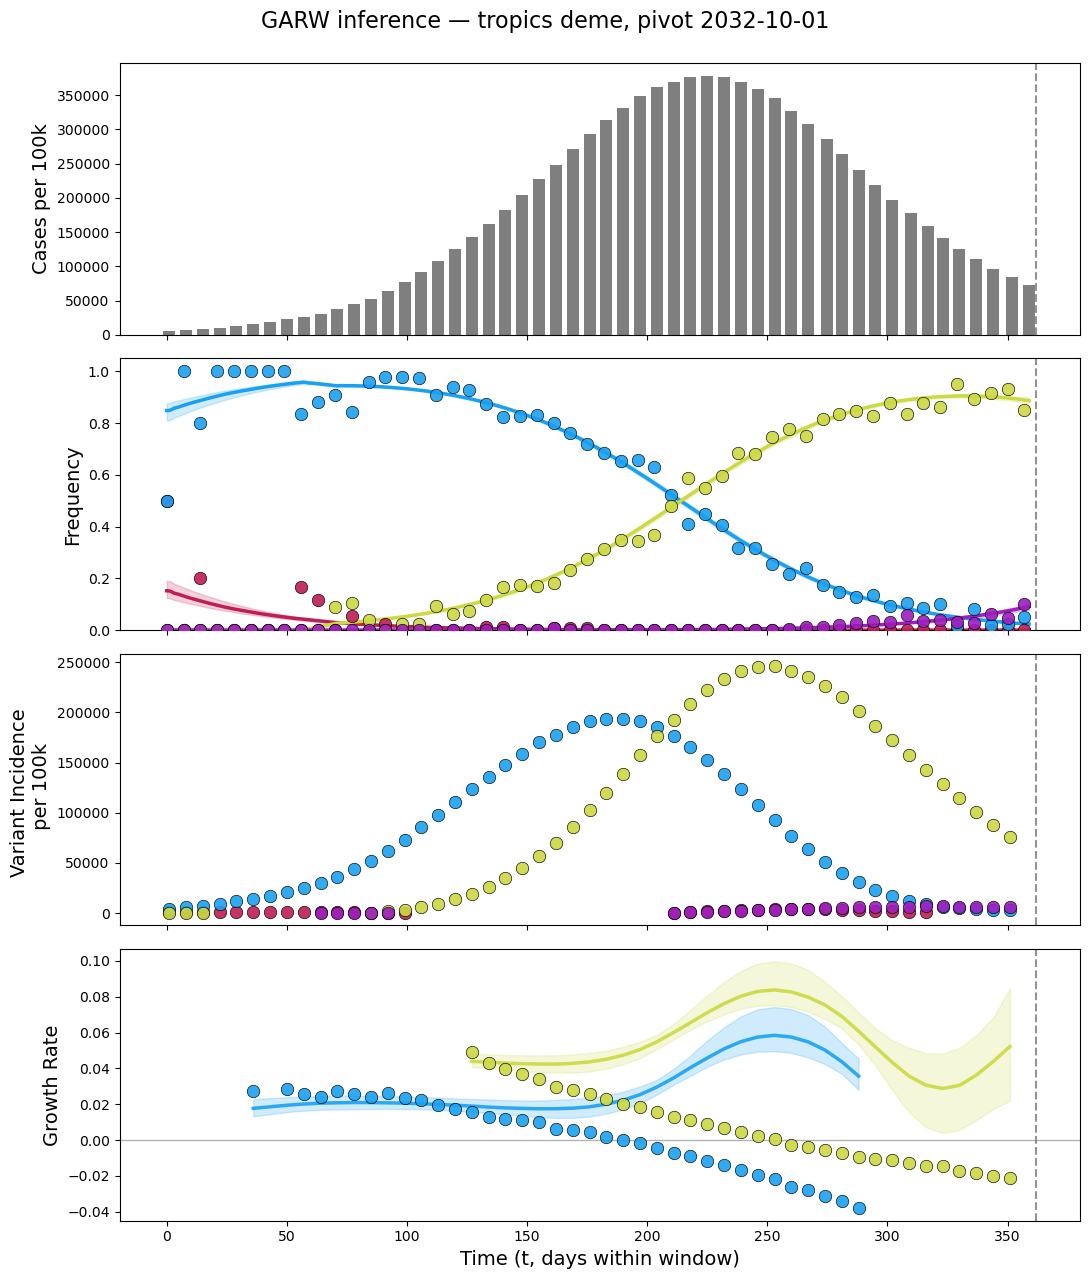

### tropics — pivot 2030-04-01  (variants [5], max MAE 0.0448)

Total cases: 9348943.0
Total sequences: 4526.0
Variant counts: [1.000e+00 2.260e+02 6.710e+02 3.611e+03 1.500e+01 2.000e+00]


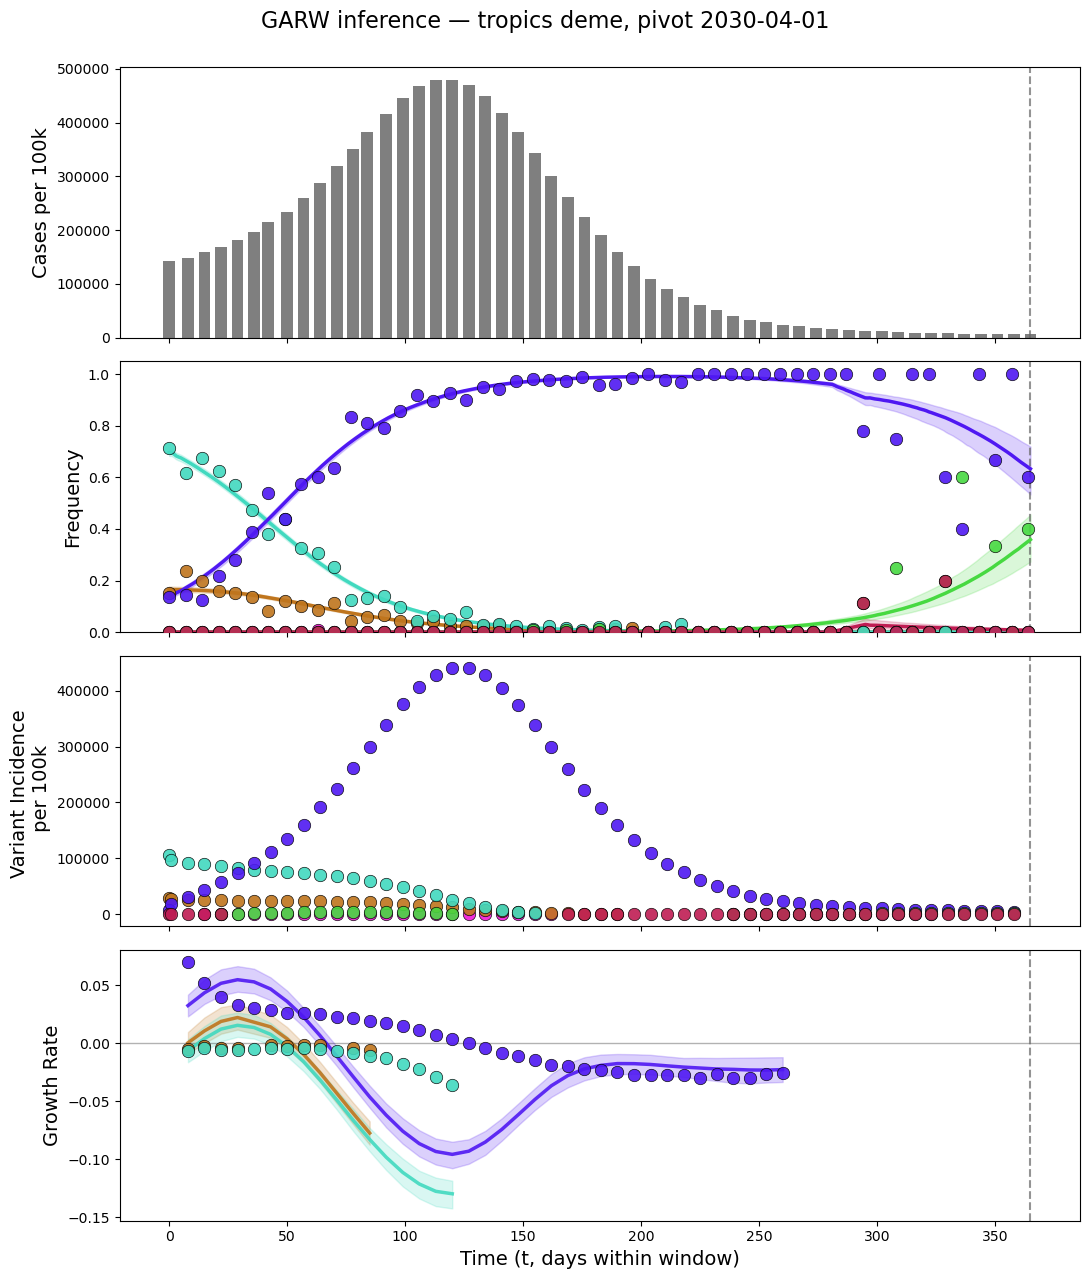

### south — pivot 2045-04-01  (variants [21, 22], max MAE 0.0435)

Total cases: 3414036.0
Total sequences: 1613.0
Variant counts: [3.340e+02 1.278e+03 1.000e+00]


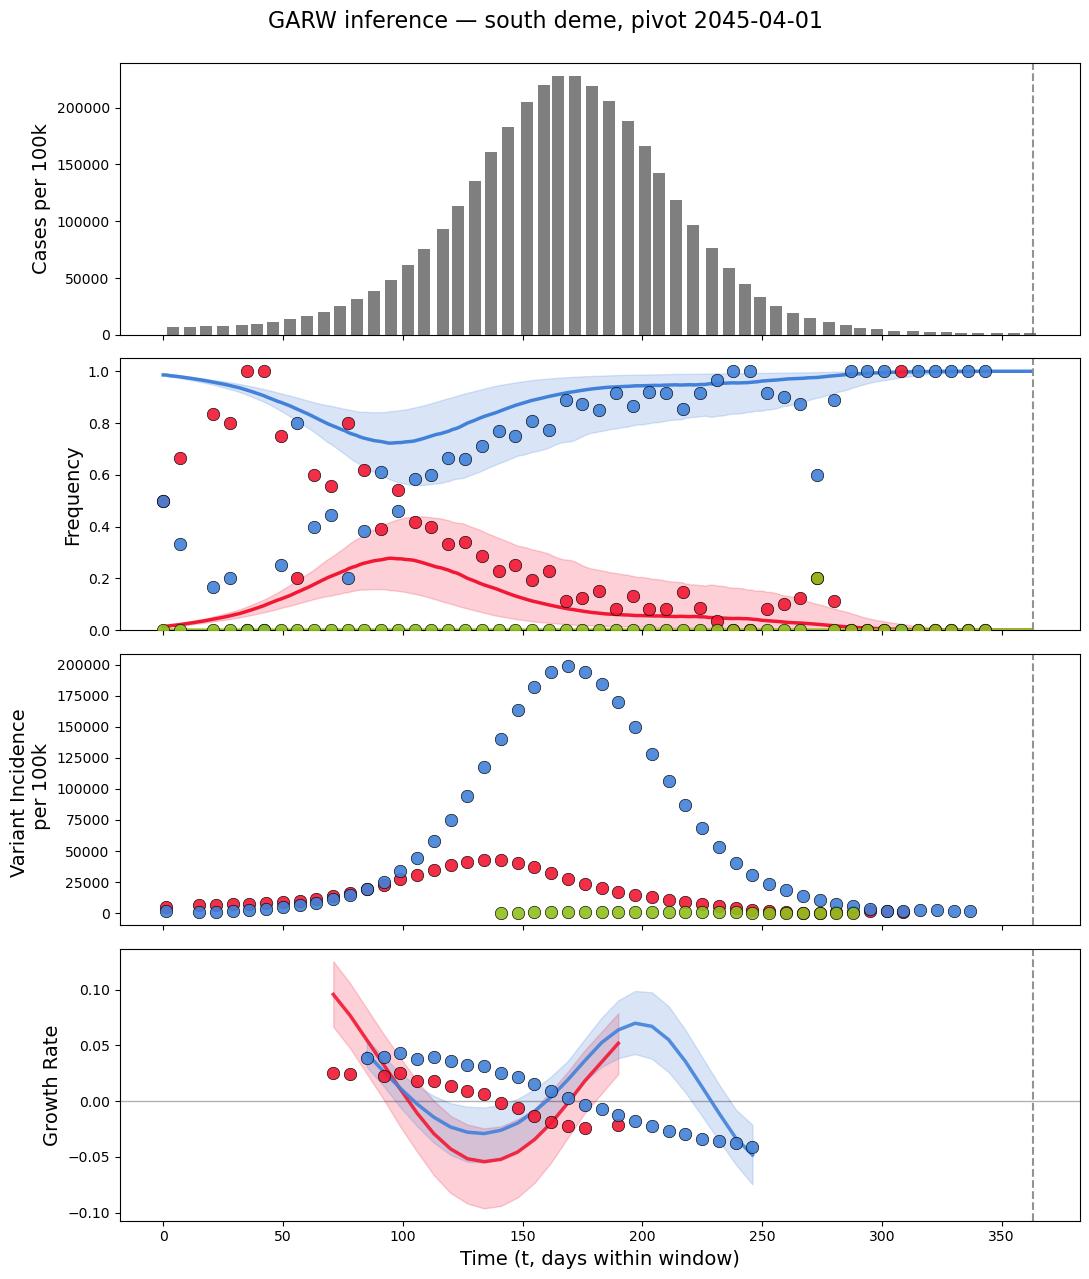

### south — pivot 2029-10-01  (variants [4], max MAE 0.0401)

Total cases: 15475926.0
Total sequences: 7302.0
Variant counts: [3.00e+00 1.51e+02 8.15e+02 6.32e+03 1.30e+01]


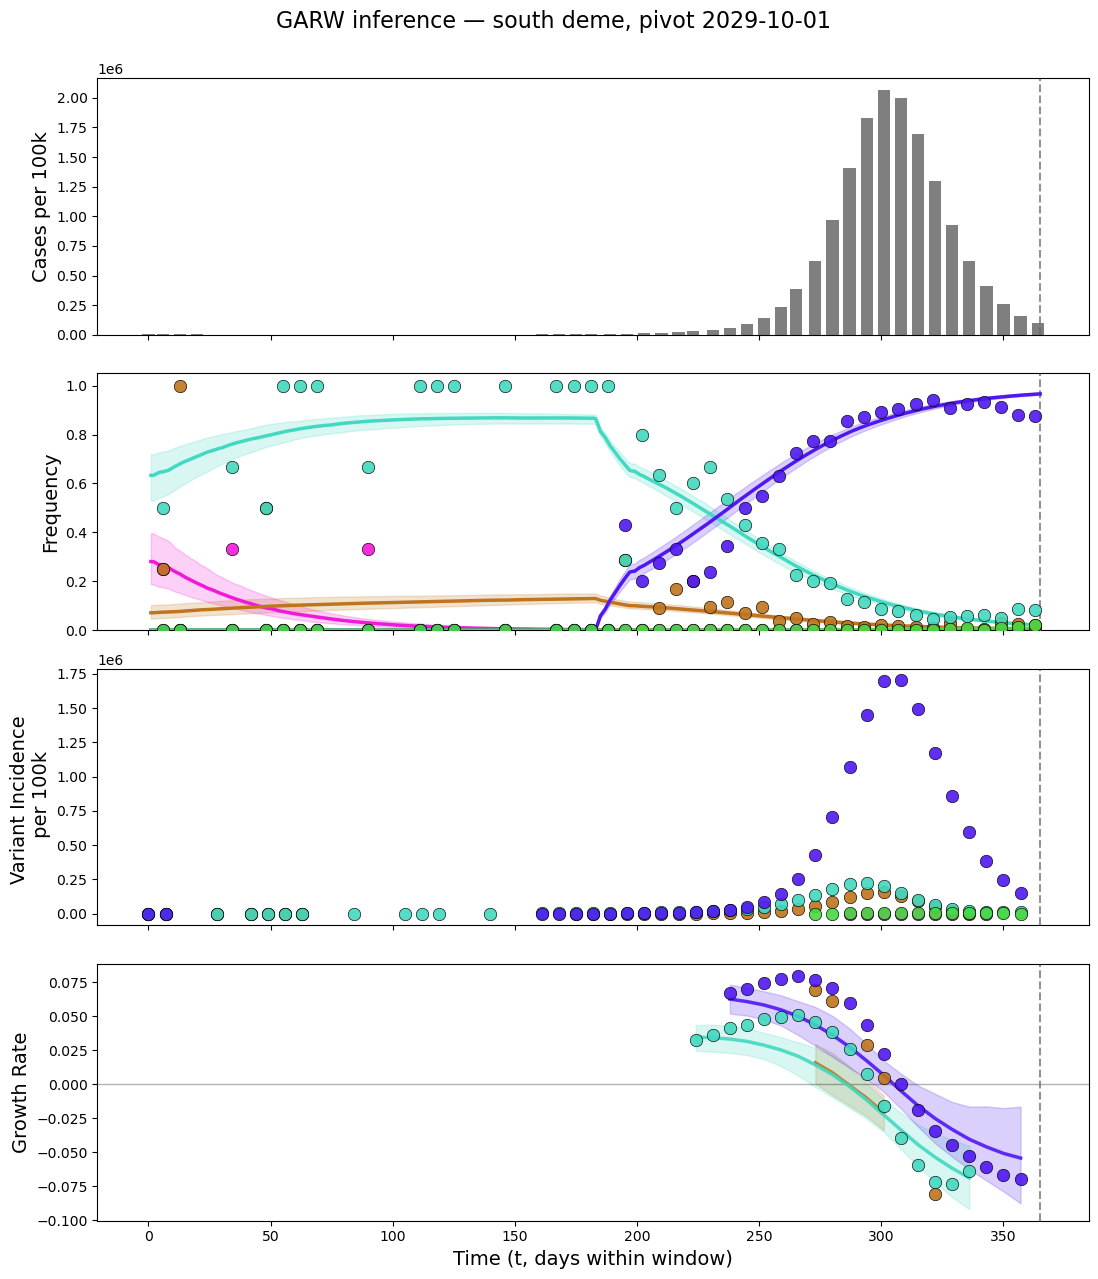

### north — pivot 2044-10-01  (variants [22], max MAE 0.0379)

Total cases: 8885475.0
Total sequences: 3988.0
Variant counts: [1.000e+00 2.700e+01 3.536e+03 4.230e+02 1.000e+00]


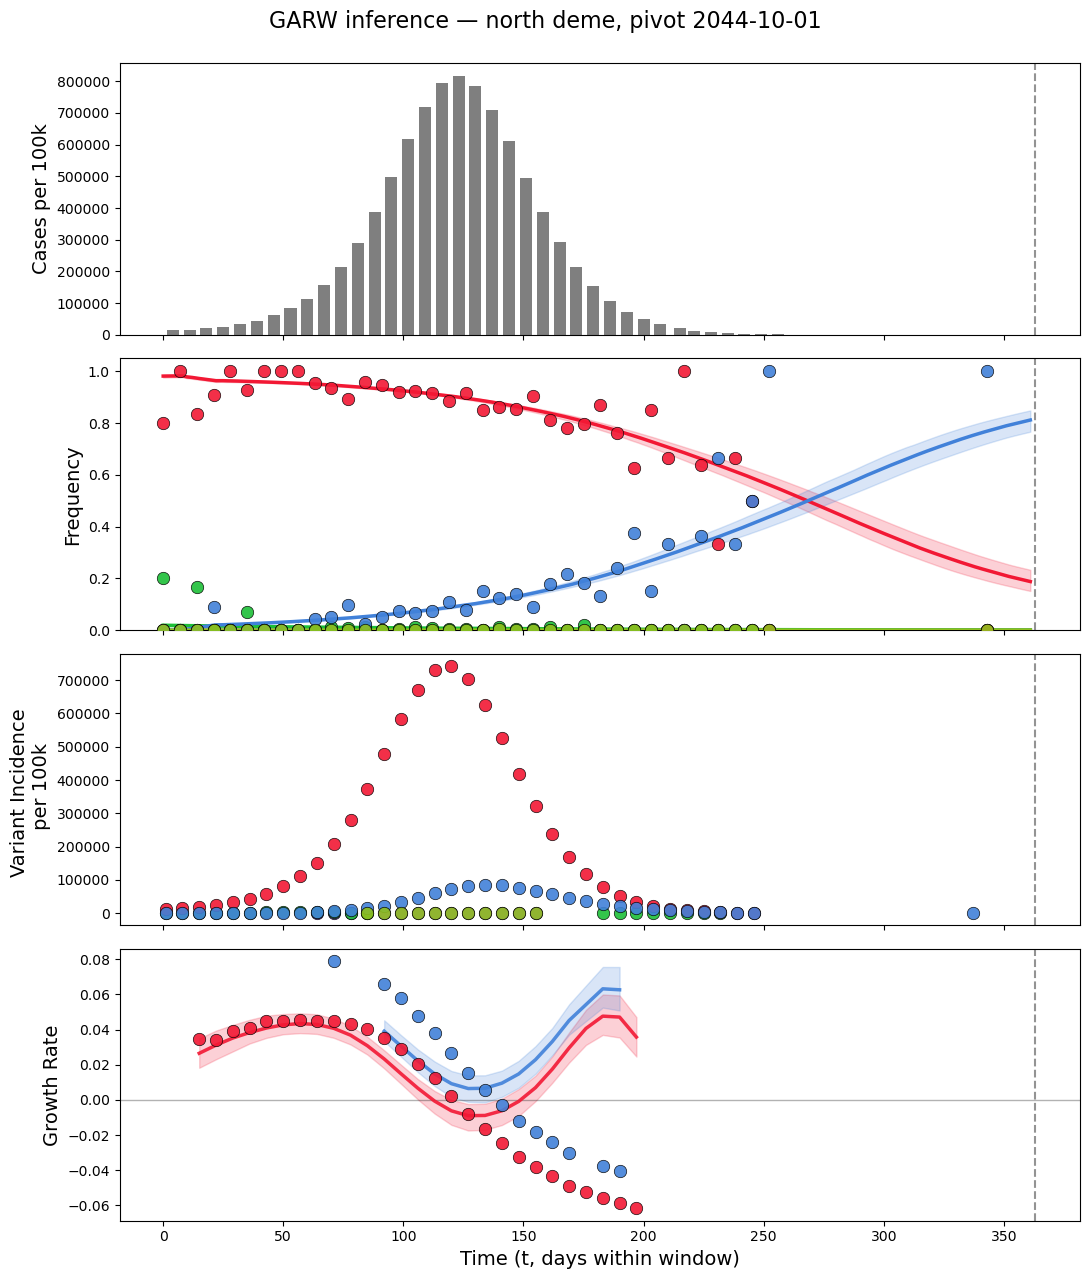

In [7]:
# Render each unique window. A window whose estimates are missing prints a skip note
# instead of aborting the loop.
for _, w in windows.iterrows():
    display(Markdown(
        f"### {w['location']} — pivot {w['pivot_date']}  "
        f"(variants {w['variants']}, max MAE {w['max_mae']:.4f})"
    ))
    try:
        plot_window_zoomin(w["pivot_date"], w["location"], MODEL, BUILD, color_map)
    except FileNotFoundError as err:
        print(f"  [skip] estimates missing for this window (scp the run-14 estimates/ dir): {err}")
    except Exception as err:  # noqa: BLE001 - finder tool, keep browsing on any window error.
        print(f"  [error] {type(err).__name__}: {err}")


In [8]:
# The chosen windows: feed these to the main-text fig-4 GARW panels and the FGA
# supplement (S6) so the example windows match across models.
print("Chosen zoom-in windows (GARW; reuse for the FGA supplement):")
display(windows[["pivot_date", "location", "variants", "max_mae"]])


Chosen zoom-in windows (GARW; reuse for the FGA supplement):


,pivot_date,location,variants,max_mae
0,2025-04-01,north,"[0, 1, 2]",0.076404
3,2032-10-01,tropics,[10],0.046981
2,2030-04-01,tropics,[5],0.044849
5,2045-04-01,south,"[21, 22]",0.043525
1,2029-10-01,south,[4],0.040084
4,2044-10-01,north,[22],0.037930
